Loading data...
Applying preprocessing steps...
Creating time domain visualizations...
Creating frequency domain visualizations...
Creating 50 Hz noise close-up figure...
Time domain figure saved to C:/Users/PC/Desktop/graphs_data_pre\S1_preprocessing_ch0_time.png
Frequency domain figure saved to C:/Users/PC/Desktop/graphs_data_pre\S1_preprocessing_ch0_frequency.png
50 Hz close-up figure saved to C:/Users/PC/Desktop/graphs_data_pre\S1_preprocessing_ch0_closeup.png
Preprocessing report figures generated and saved to C:/Users/PC/Desktop/graphs_data_pre/


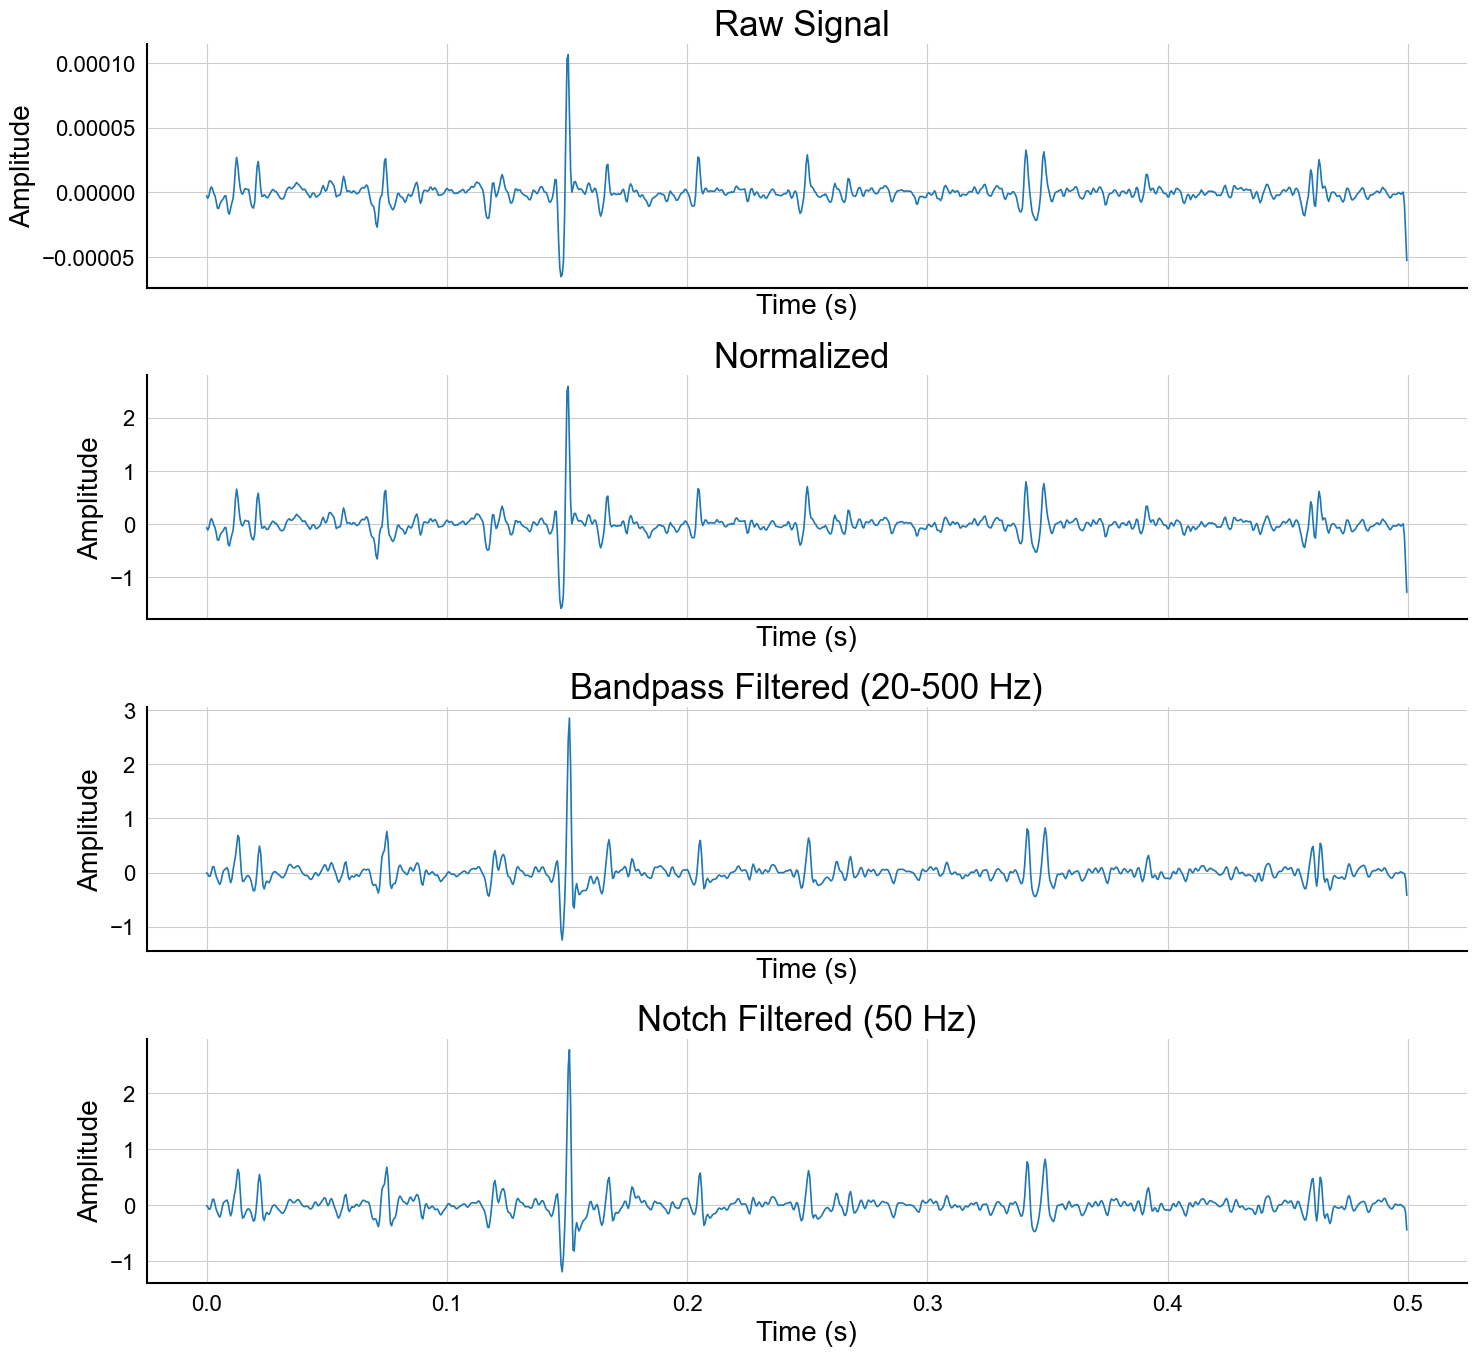

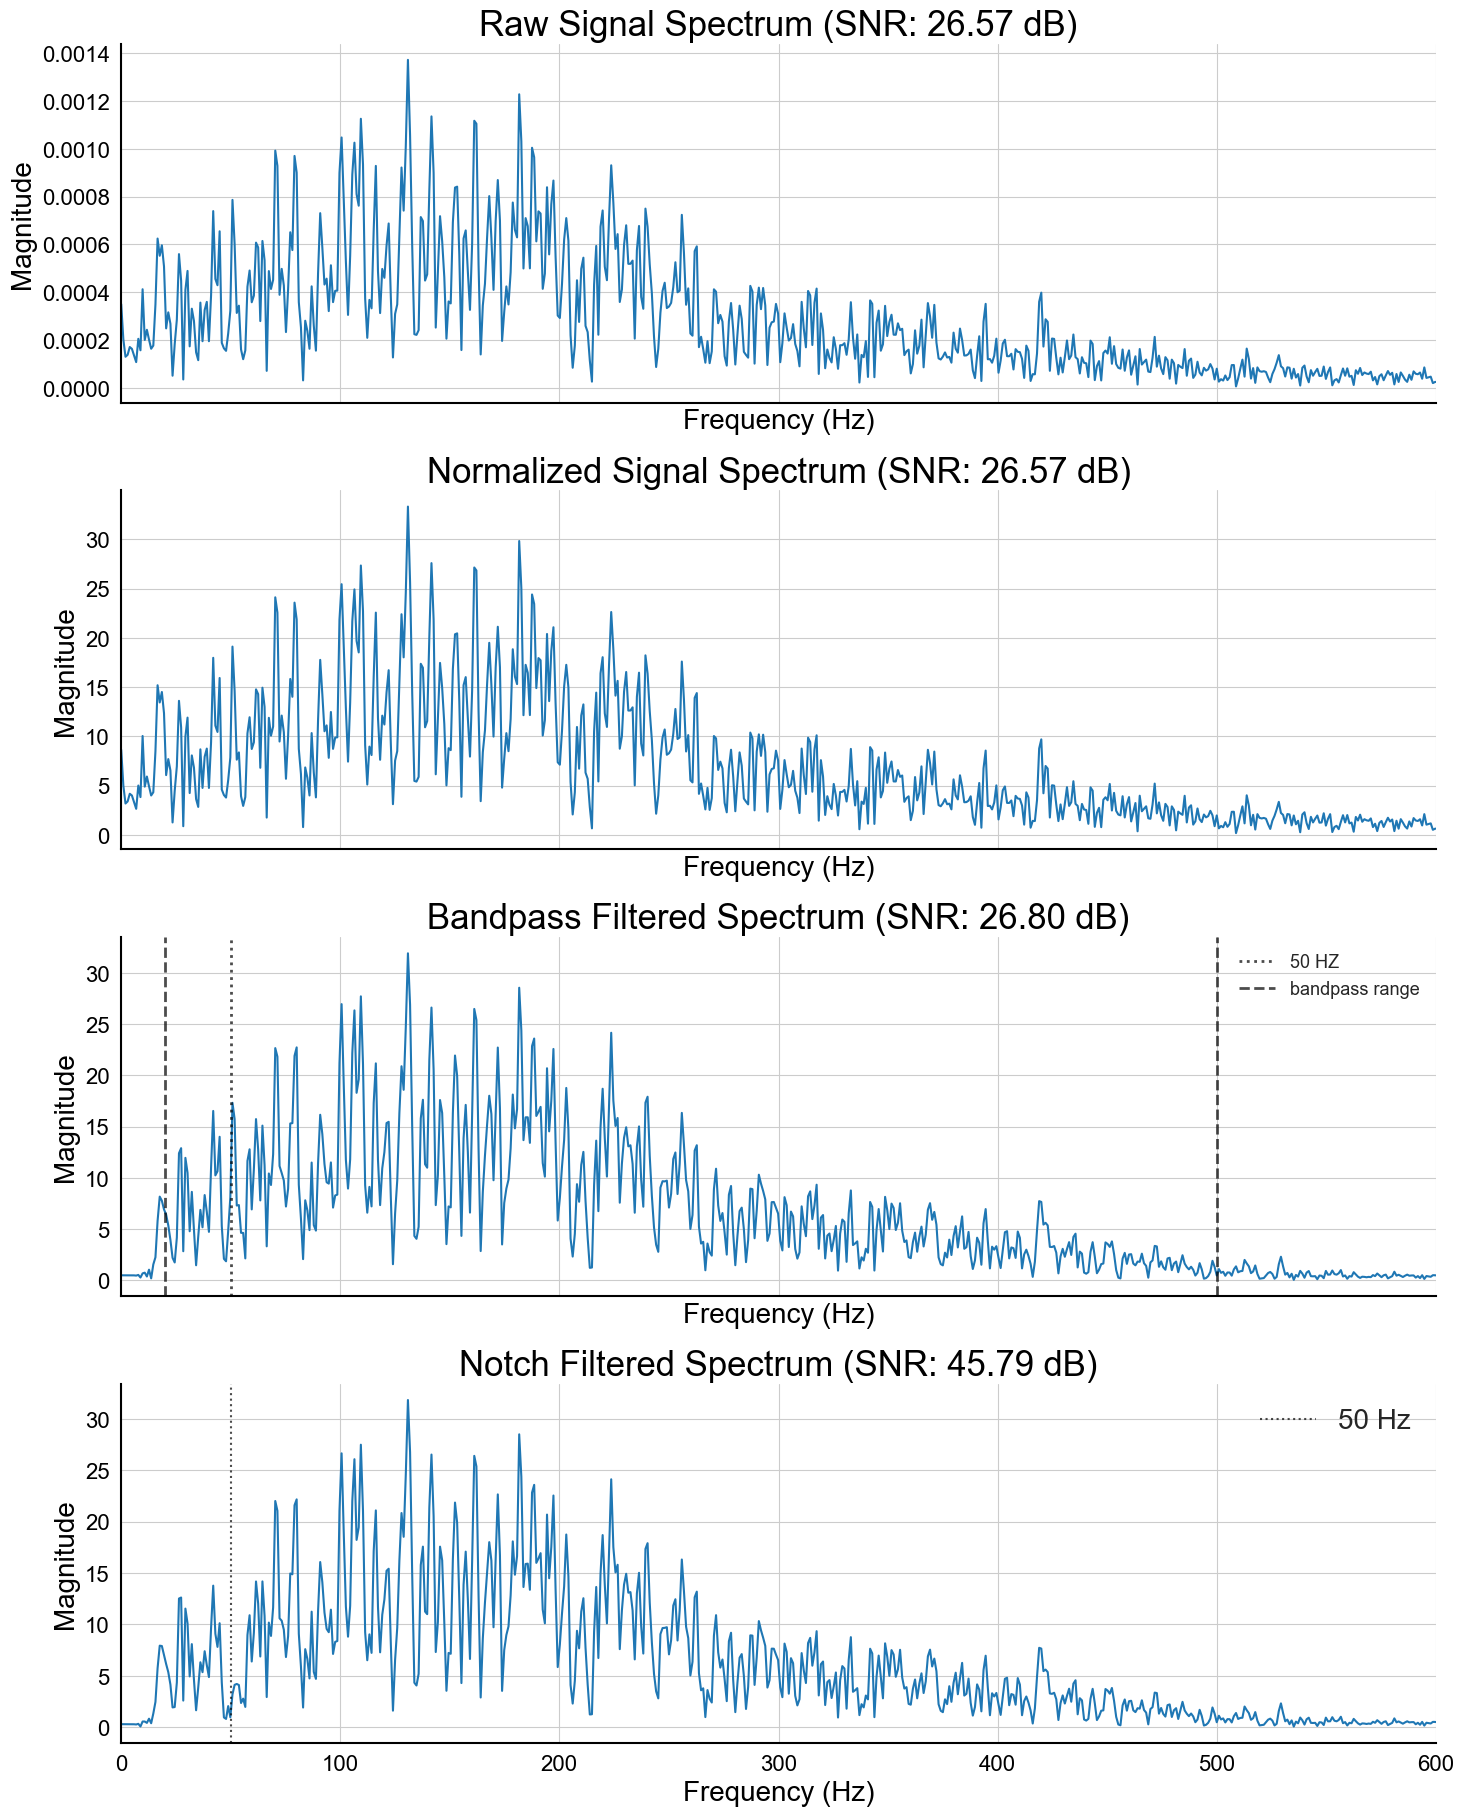

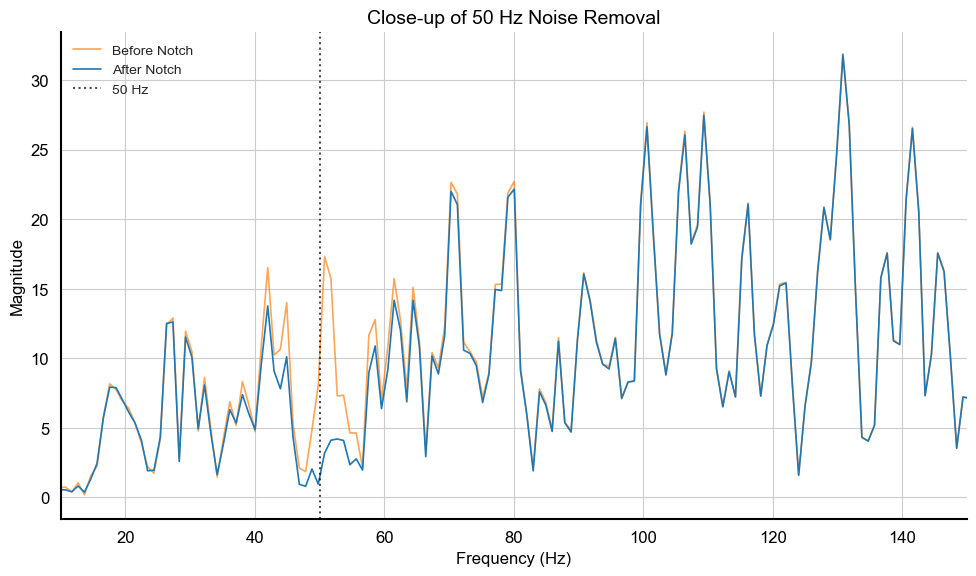

In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.fft import fft, fftfreq
import seaborn as sns

# Set plot style for publication-quality figures
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.5)

# Set global parameters for dark axes
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'

def visualize_preprocessing_steps_separated(data_path, file_name, channel_idx=0, time_samples=1000,
                                            save_path=None, dpi=300):
    """
    Visualize the EMG preprocessing steps with time and frequency domains in separate figures.

    Parameters:
        data_path (str): Path to the data directory
        file_name (str): Name of the .mat file
        channel_idx (int): Channel to visualize
        time_samples (int): Number of time samples to display
        save_path (str): Path to save the figures (None = display only)
        dpi (int): DPI for saved figures
    """
    from nina_funcs import (get_data, normalise, filter_data, notch_filter)

    # Load raw data
    print("Loading data...")
    data = get_data(data_path, file_name)

    # Extract the specified channel for visualization
    raw_data = data.iloc[:time_samples, channel_idx]

    # Apply preprocessing steps
    print("Applying preprocessing steps...")
    train_reps = [1, 2, 4, 6]  # Training repetitions

    # Normalize
    data_normalized = normalise(data, train_reps)
    normalized_data = data_normalized.iloc[:time_samples, channel_idx]

    # Bandpass filter
    data_filtered = filter_data(data_normalized, f=(20, 500), butterworth_order=4, btype='bandpass')
    filtered_data = data_filtered.iloc[:time_samples, channel_idx]

    # Notch filter
    data_notch = notch_filter(data=data_filtered, f0=50, Q=5, fs=2000)
    notched_data = data_notch.iloc[:time_samples, channel_idx]

    # Compute FFT for each processing stage
    fs = 2000  # Sampling frequency (Hz)
    n_fft = 2048  # For better frequency resolution

    # Frequency axis
    freqs = fftfreq(n_fft, 1/fs)[:n_fft//2]

    # Compute FFTs
    fft_raw = np.abs(fft(raw_data.to_numpy(), n=n_fft))[:n_fft//2]
    fft_normalized = np.abs(fft(normalized_data.to_numpy(), n=n_fft))[:n_fft//2]
    fft_filtered = np.abs(fft(filtered_data.to_numpy(), n=n_fft))[:n_fft//2]
    fft_notched = np.abs(fft(notched_data.to_numpy(), n=n_fft))[:n_fft//2]

    # Calculate SNR
    snr_raw = compute_snr(raw_data, noise_freq=50, fs=2000)
    snr_normalized = compute_snr(normalized_data, noise_freq=50, fs=2000)
    snr_filtered = compute_snr(filtered_data, noise_freq=50, fs=2000)
    snr_notched = compute_snr(notched_data, noise_freq=50, fs=2000)

    # Create time domain figure
    print("Creating time domain visualizations...")
    fig_time, axes_time = plt.subplots(4, 1, figsize=(15, 15), sharex=True)
    time_axis = np.arange(time_samples) / fs

    # Apply dark axis styling to each subplot (only bottom and left spines)
    for ax in axes_time:
        ax.spines['bottom'].set_color('black')
        ax.spines['left'].set_color('black')
        ax.spines['bottom'].set_linewidth(1.5)
        ax.spines['left'].set_linewidth(1.5)
        ax.tick_params(axis='x', colors='black', labelsize=16)
        ax.tick_params(axis='y', colors='black', labelsize=16)
        # Use seaborn despine to remove top and right spines
        sns.despine(ax=ax)

    axes_time[0].plot(time_axis, raw_data, color='#1f77b4')
    axes_time[0].set_title(f"Raw Signal ", fontsize=25, color='black')
    axes_time[0].set_ylabel('Amplitude', fontsize=20, color='black')
    axes_time[0].set_xlabel('Time (s)', fontsize=20, color='black')

    axes_time[1].plot(time_axis, normalized_data, color='#1f77b4')
    axes_time[1].set_title(f"Normalized ", fontsize=25, color='black')
    axes_time[1].set_ylabel('Amplitude', fontsize=20, color='black')
    axes_time[1].set_xlabel('Time (s)', fontsize=20, color='black')

    axes_time[2].plot(time_axis, filtered_data, color='#1f77b4')
    axes_time[2].set_title(f"Bandpass Filtered (20-500 Hz)", fontsize=25, color='black')
    axes_time[2].set_ylabel('Amplitude', fontsize=20, color='black')
    axes_time[2].set_xlabel('Time (s)', fontsize=20, color='black')

    axes_time[3].plot(time_axis, notched_data, color='#1f77b4')
    axes_time[3].set_title(f"Notch Filtered (50 Hz)", fontsize=25, color='black')
    axes_time[3].set_ylabel('Amplitude', fontsize=20, color='black')
    axes_time[3].set_xlabel('Time (s)', fontsize=20, color='black')

    fig_time.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle

    # Create frequency domain figure
    print("Creating frequency domain visualizations...")
    fig_freq, axes_freq = plt.subplots(4, 1, figsize=(15, 20), sharex=True)
    freq_domain = 600  # Extended frequency domain visualization

    # Apply dark axis styling to each subplot (only bottom and left spines)
    for ax in axes_freq:
        ax.spines['bottom'].set_color('black')
        ax.spines['left'].set_color('black')
        ax.spines['bottom'].set_linewidth(1.5)
        ax.spines['left'].set_linewidth(1.5)
        ax.tick_params(axis='x', colors='black', labelsize=16)
        ax.tick_params(axis='y', colors='black', labelsize=16)
        # Use seaborn despine to remove top and right spines
        sns.despine(ax=ax)

    axes_freq[0].plot(freqs, fft_raw, color='#1f77b4', linewidth=1.5)
    axes_freq[0].set_title(f"Raw Signal Spectrum (SNR: {snr_raw:.2f} dB)", fontsize=25, color='black')
    axes_freq[0].set_ylabel('Magnitude', fontsize=20, color='black')
    axes_freq[0].set_xlabel('Frequency (Hz)', fontsize=20, color='black')
    axes_freq[0].set_xlim(0, freq_domain)

    axes_freq[1].plot(freqs, fft_normalized, color='#1f77b4', linewidth=1.5)
    axes_freq[1].set_title(f"Normalized Signal Spectrum (SNR: {snr_normalized:.2f} dB)", fontsize=25, color='black')
    axes_freq[1].set_ylabel('Magnitude', fontsize=20, color='black')
    axes_freq[1].set_xlabel('Frequency (Hz)', fontsize=20, color='black')
    axes_freq[1].set_xlim(0, freq_domain)

    axes_freq[2].plot(freqs, fft_filtered, color='#1f77b4', linewidth=1.5)
    axes_freq[2].set_title(f"Bandpass Filtered Spectrum (SNR: {snr_filtered:.2f} dB)", fontsize=25, color='black')
    axes_freq[2].set_ylabel('Magnitude', fontsize=20, color='black')
    axes_freq[2].set_xlabel('Frequency (Hz)', fontsize=20, color='black')
    axes_freq[2].set_xlim(0, freq_domain)
    axes_freq[2].axvline(x=50, color='black', linestyle='dotted', alpha=0.7, linewidth=2, label='50 HZ')
    axes_freq[2].axvline(x=20, color='black', linestyle='dashed', alpha=0.7, linewidth=2, label='bandpass range')
    axes_freq[2].axvline(x=500, color='black', linestyle='dashed', alpha=0.7, linewidth=2)
    axes_freq[2].legend(fontsize=13)

    axes_freq[3].plot(freqs, fft_notched, color='#1f77b4', linewidth=1.5)
    axes_freq[3].set_title(f"Notch Filtered Spectrum (SNR: {snr_notched:.2f} dB)", fontsize=25, color='black')
    axes_freq[3].set_ylabel('Magnitude', fontsize=20, color='black')
    axes_freq[3].set_xlabel('Frequency (Hz)', fontsize=20, color='black')
    axes_freq[3].set_xlim(0, freq_domain)
    axes_freq[3].axvline(x=50, color='black', linestyle='dotted', alpha=0.7, linewidth=1.5, label='50 Hz')
    axes_freq[3].legend(fontsize=20) 
    fig_freq.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle


    # Create separate figure for 50 Hz noise close-up
    print("Creating 50 Hz noise close-up figure...")
    fig_closeup = plt.figure(figsize=(10, 6))
    ax_closeup = fig_closeup.add_subplot(111)
    
    # Apply dark axis styling to closeup figure (only bottom and left spines)
    ax_closeup.spines['bottom'].set_color('black')
    ax_closeup.spines['left'].set_color('black')
    ax_closeup.spines['bottom'].set_linewidth(1.5)
    ax_closeup.spines['left'].set_linewidth(1.5)
    ax_closeup.tick_params(axis='x', colors='black', labelsize=12)
    ax_closeup.tick_params(axis='y', colors='black', labelsize=12)
    # Use seaborn despine to remove top and right spines
    sns.despine(ax=ax_closeup)
    
    ax_closeup.plot(freqs, fft_filtered, color='#ff7f0e', alpha=0.7, label='Before Notch', linewidth=1.2)
    ax_closeup.plot(freqs, fft_notched, color='#1f77b4', label='After Notch', linewidth=1.2)
    ax_closeup.axvline(x=50, color='black', linestyle='dotted', alpha=0.7, linewidth=1.5, label='50 Hz')
    ax_closeup.set_xlim(10, 150)
    ax_closeup.set_title('Close-up of 50 Hz Noise Removal', fontsize=14, color='black')
    ax_closeup.set_xlabel('Frequency (Hz)', fontsize=12, color='black')
    ax_closeup.set_ylabel('Magnitude', fontsize=12, color='black')
    ax_closeup.legend(fontsize=10)

    fig_closeup.tight_layout()

    # Save or display
    if save_path:
        base_name = os.path.splitext(os.path.basename(save_path))[0]
        output_dir = os.path.dirname(save_path)
        time_fig_path = os.path.join(output_dir, f"{base_name}_time.png")
        freq_fig_path = os.path.join(output_dir, f"{base_name}_frequency.png")
        closeup_fig_path = os.path.join(output_dir, f"{base_name}_closeup.png")

        fig_time.savefig(time_fig_path, dpi=dpi, bbox_inches='tight')
        fig_freq.savefig(freq_fig_path, dpi=dpi, bbox_inches='tight')
        fig_closeup.savefig(closeup_fig_path, dpi=dpi, bbox_inches='tight')

        print(f"Time domain figure saved to {time_fig_path}")
        print(f"Frequency domain figure saved to {freq_fig_path}")
        print(f"50 Hz close-up figure saved to {closeup_fig_path}")
    else:
        plt.show()

    return fig_time, fig_freq, fig_closeup

def compute_snr(signal, noise_freq=50, fs=2000):
    """
    Compute Signal-to-Noise Ratio focusing on the noise at a specific frequency.

    Parameters:
        signal (pd.Series or np.array): The signal to analyze
        noise_freq (float): The frequency of the noise (Hz)
        fs (float): Sampling frequency (Hz)

    Returns:
        float: SNR in dB
    """
    # Compute FFT
    if isinstance(signal, pd.Series):
        signal = signal.to_numpy()

    fft_signal = np.abs(fft(signal))
    freqs = fftfreq(len(signal), 1/fs)

    # Find power at noise frequency (with a small bandwidth)
    bandwidth = 2  # Hz around noise frequency
    noise_indices = (freqs >= noise_freq-bandwidth/2) & (freqs <= noise_freq+bandwidth/2)
    noise_power = np.sum(fft_signal[noise_indices]**2)

    # Total power
    total_power = np.sum(fft_signal**2)

    # Compute SNR
    if noise_power > 0:
        snr = 10 * np.log10((total_power - noise_power) / noise_power)
    else:
        snr = float('inf')  # No noise at the specified frequency

    return snr

def create_preprocessing_summary_report_separated(data_path, file_name, output_dir, channel_idx=0):
    """
    Create a visual report of preprocessing steps with separated time and frequency domain figures.

    Parameters:
        data_path (str): Path to the data directory
        file_name (str): Name of the .mat file
        output_dir (str): Directory to save the figures
        channel_idx (int): Channel to visualize
    """
    os.makedirs(output_dir, exist_ok=True)
    subject_id = os.path.basename(file_name).split('_')[0]

    # Time and frequency domain visualization of preprocessing steps
    base_path = os.path.join(output_dir, f"{subject_id}_preprocessing_ch{channel_idx}")
    visualize_preprocessing_steps_separated(data_path, file_name, channel_idx=channel_idx,
                                            time_samples=1000, save_path=f"{base_path}.png")

    print(f"Preprocessing report figures generated and saved to {output_dir}")

# Example usage
if __name__ == "__main__":
    # Example paths - adjust these to your actual paths
    input_folder = 'E:/DB2/'
    file_name = 'S1_E1_A1.mat'  # Adjust to your file
    output_dir = 'C:/Users/PC/Desktop/graphs_data_pre/'

    # Create directory for report figures
    os.makedirs(output_dir, exist_ok=True)

    # Generate a preprocessing report with separated figures for channel 0
    create_preprocessing_summary_report_separated(input_folder, file_name, output_dir, channel_idx=0)